# The D-optimality ceiling, and how much of it the method captures

How much can shot *allocation* be worth, at most, with the total number of shots fixed -- and
how much of that does the adaptive method actually get?

Both questions are answered **entirely in information space**: no GST fits, no sampled data,
no conversion to any error metric. That restriction is the point, because it is what makes the
comparison airtight.

### The bound

The Fisher information is an expectation over data with a closed form, so it comes straight
from the model:

    A_s = sum_beta (grad p_{s,beta})(grad p_{s,beta})^T / p_{s,beta}   (per shot of circuit s)
    H(rho) = sum_s rho_s A_s                                          (rho_s = shots on s)

For **any** allocation with `sum_s rho_s = N`, `H(rho)` is exactly that sum -- information adds
over independent shots. Maximising `log det H(rho)` over the simplex is concave, so its optimum
is global: no allocation of N shots can make `det H` larger. That is the ceiling, and it is a
theorem rather than an estimate.

Reported as a **shot multiplier**, since `det(H)^(1/r)` is linear in shots:

    c = (det H_opt / det H_unif)^(1/r)

### What is measured against it

Every run saved `final_shots_per_circuit.npy` -- the allocation it actually used. Feeding that
into the same formula gives the D-efficiency the method really achieved, with nothing assumed
in between. The achieved value **cannot** exceed the ceiling; that is what makes this version
of the comparison safe.

### What this does NOT bound

`c` bounds `det H`, which weights all identifiable directions equally. **It is not a bound on
infidelity or diamond distance**, which weight directions by a metric and can improve by more
than `det H` does. An earlier version of this notebook drew the ceiling on an infidelity axis;
that line was not a floor, and a measured point falling below it was not a contradiction.
Infidelity appears here only in the last section, as a separate empirical observation.

### Three qualifiers on the number itself

1. It is the ceiling **given the identifiability baseline** (5% uniform here) -- 4.14x at 2%,
   2.33x at 70%. As the baseline shrinks the pseudo-determinant starts rewarding rank collapse,
   so an unconstrained supremum does not exist.
2. It is the ceiling **for this circuit set**. A method that also chooses circuits (FPR) is not
   bounded by it.
3. It is evaluated **at the true parameters**, which is what makes it an oracle no real method
   can match -- but the retained rank depends on where you stand (27 at the ideal target, 33 at
   the truth, 43 at interior points), so the number and the evaluation point are not separable.

In [31]:
import json
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd

SSE = Path.cwd()                                  # run from seed_sweep_experiments
sys.path.insert(0, str(SSE))
sys.path.insert(0, str(SSE.parent))               # GST_POUNDERS, for adaptive_shots

from gst_seed_experiment import (ExperimentConfig, GSTProblem, _make_parameterized_model,
                                 _dense)
import adaptive_shots as ashots

CONFIG = SSE / "experiment_config.json"
SEED = 101
BASELINE_FRAC = 0.05        # identifiability baseline; see qualifier 1 above
FW_ITERS = 2000             # 200 (the allocator default) is not converged for a one-shot
                            # allocation of an entire budget, and an unconverged solve
                            # UNDERSTATES the ceiling
RIDGE = 1e-9
PROB_FLOOR = 1e-9           # both must match allocate_shots_per_circuit's defaults exactly

cfg = ExperimentConfig.from_json(CONFIG)
t0 = time.time()
prob = GSTProblem(cfg, SEED)
n_circ = len(prob.circuits)
row_index = np.repeat(np.arange(n_circ), prob.outcomes_per_circuit)

print(f"{cfg.modelpack_1q}  {cfg.parameterization}  noise={cfg.noise_model}")
print(f"ladder {list(cfg.max_lengths)}")
print(f"{n_circ} circuits x {prob.outcomes_per_circuit} outcomes = {len(row_index)} rows, "
      f"{prob.n} parameters   [{time.time()-t0:.1f}s]")

smq1Q_XYZI  CPTPLND  noise=lindblad_hard
ladder [1, 2, 4, 8, 16, 32, 64]
1918 circuits x 2 outcomes = 3836 rows, 72 parameters   [0.9s]


## The Jacobian at the true parameters

The truth model is synthetic, so it is known exactly -- no fitting needed. It is built from
per-gate Lindblad (HSCA) error generators, which are CPTP by construction and therefore
in-model for a CPTPLND fit; the assert below checks that rather than trusting it.

`p` and `dp/dtheta` come **straight from that model**, not from pushing its parameter vector
through `prob.base_model`. Both are CPTPLND with the same parameter count, but `base_model` is
built by re-parameterizing an already-CPTPLND model and the two layouts are not
interchangeable -- feeding one's vector to the other silently yields a different model, and an
8% different ceiling.

Using the truth's own parameterization is harmless: a D-efficiency **ratio** is invariant under
reparameterization, since `H -> S'HS` and `S` cancels between numerator and denominator.

In [32]:
def pj_from_model(model, circuits):
    """p and dp/dtheta for every (circuit, outcome) row, in the model's own parameterization."""
    circuits = list(circuits)
    pr = model.bulk_probabilities(circuits)
    dp = model.sim.bulk_dprobs(circuits)
    pv, rows = [], []
    for c in circuits:
        for o in model.probabilities(c).keys():
            pv.append(float(pr[c].get(o, 0.0)))
            rows.append(np.asarray(dp[c][o], dtype=float))
    return np.asarray(pv, dtype=float), np.vstack(rows)


t0 = time.time()
truth = _make_parameterized_model(prob.truth_model, cfg.parameterization,
                                  ideal_model=prob.raw_target_model)
conv_err = max(
    float(np.max(np.abs(_dense(truth.operations[l]) - _dense(prob.truth_model.operations[l]))))
    for l in prob.truth_model.operations.keys())
assert conv_err < 1e-10, f"truth not representable in {cfg.parameterization}: {conv_err:.2e}"
print(f"truth -> {cfg.parameterization} exact to {conv_err:.2e}")

p, J = pj_from_model(truth, prob.circuits)
print(f"Jacobian {J.shape} at the TRUE parameters   [{time.time()-t0:.1f}s]")
print(f"probabilities in [{p.min():.3e}, {p.max():.3e}]")

truth -> CPTPLND exact to 3.85e-15
Jacobian (3836, 72) at the TRUE parameters   [2.6s]
probabilities in [5.000e-04, 9.995e-01]


## The ceiling

`H_unif` spreads the budget evenly over every circuit -- which is exactly what `lm` does (it
puts the same number of shots on all 1918 circuits). `H_opt` places `BASELINE_FRAC` uniformly
and hands the rest to a Frank-Wolfe solve of the D-optimal problem.

Both designs are compared **inside one fixed subspace**, the identifiable subspace of the
uniform design. Taking each design's own pseudo-determinant is not stable enough: the smallest
identifiable eigenvalue sits near the cutoff, so the retained rank flips between 40 and 41 from
one seed to the next, and a ratio of determinants over different numbers of eigenvalues means
nothing. Fixing the subspace also makes the result conservative -- information the optimal
design places outside it is ignored rather than credited.

In [33]:
def H_of(rho):
    """H(rho) = sum_s rho_s A_s + ridge*I -- identical to the allocator's _H_design."""
    w = np.asarray(rho, dtype=float)[row_index] / np.maximum(p, PROB_FLOOR)
    return (J * w[:, None]).T @ J + RIDGE * np.eye(J.shape[1])


def frank_wolfe(N_alloc, baseline, iters=FW_ITERS):
    """Relaxed D-optimal allocation: the same iteration allocate_shots_per_circuit runs, minus
    the integer rounding.  The relaxed optimum is the right quantity for a ceiling anyway, and
    upper-bounds the integer one."""
    H0 = H_of(baseline)
    inv_p = 1.0 / np.maximum(p, PROB_FLOOR)
    rho = np.full(n_circ, N_alloc / n_circ)
    gap = np.inf
    for it in range(iters):
        Hinv = ashots.stable_inverse(H0 + (J * ((rho[row_index] * inv_p)[:, None])).T @ J)
        rowq = np.einsum("ij,ji->i", J, Hinv @ J.T) * inv_p
        sc = np.zeros(n_circ)
        np.add.at(sc, row_index, rowq)
        i_star = int(np.argmax(sc))
        gap = float(N_alloc * sc[i_star] - sc @ rho)
        if gap <= 1e-8:
            break
        gamma = 2.0 / (it + 2.0)
        rho *= (1.0 - gamma)
        rho[i_star] += gamma * N_alloc
    return rho, gap


# The subspace is fixed by the uniform design.  Scaling H leaves its eigenVECTORS unchanged, so
# this basis does not depend on the budget and is computed once and reused for every run below.
N_REF = 2521 * n_circ
_ev, _V = np.linalg.eigh(0.5 * (H_of(np.full(n_circ, N_REF / n_circ))
                                + H_of(np.full(n_circ, N_REF / n_circ)).T))
V = _V[:, _ev > ashots.RANK_CUTOFF * _ev[-1]]
RANK = V.shape[1]


def d_efficiency(rho):
    """(det H(rho) / det H_uniform)^(1/rank), the uniform reference taken at rho's own budget."""
    N = float(np.sum(rho))
    ev_u = np.linalg.eigvalsh(V.T @ H_of(np.full(n_circ, N / n_circ)) @ V)
    ev_r = np.linalg.eigvalsh(V.T @ H_of(rho) @ V)
    return float(np.exp((np.sum(np.log(ev_r)) - np.sum(np.log(ev_u))) / RANK))


t0 = time.time()
baseline = np.full(n_circ, BASELINE_FRAC * N_REF / n_circ)
rho_fw, fw_gap = frank_wolfe((1.0 - BASELINE_FRAC) * N_REF, baseline)
rho_oracle = baseline + rho_fw
CEILING = d_efficiency(rho_oracle)

print(f"identifiable rank {RANK} of {prob.n}   FW gap {fw_gap:.2e}   [{time.time()-t0:.1f}s]")
print()
print("=" * 68)
print(f"  CEILING  {CEILING:.3f}x      no allocation of N shots can exceed this")
print("=" * 68)

identifiable rank 33 of 72   FW gap 5.35e-01   [4.7s]

  CEILING  3.584x      no allocation of N shots can exceed this


### Is the design actually optimal?

Kiefer-Wolfowitz: with weights `w_s` summing to 1 and `g_s = tr(H(w)^-1 A_s)`, a design is
D-optimal **iff** `max_s g_s = r`, and `max_s g_s >= r` for any design. The `w`-weighted mean of
`g_s` is exactly `r` for *every* design, which doubles as an arithmetic check on the whole
calculation -- it exercises the Fisher matrices, the subspace projection and the leverage
computation at once. (Weighted, not plain: the optimal design's weights are far from uniform.)

`max g_s / r` for the *uniform* design is a cheap headroom detector -- one matrix inverse and a
pass over circuits, no Frank-Wolfe. It measures imbalance, **not** gain: a clean-gate device
triples it while the ceiling barely moves, because `det H` still needs every direction
covered.

In [34]:
def leverage(rho):
    """g_s = tr(H(w)^-1 A_s) for w = rho/sum(rho), plus the w-weighted mean (= rank)."""
    N = float(np.sum(rho))
    Hw = H_of(rho)
    Hinv = V @ np.linalg.inv(V.T @ Hw @ V) @ V.T          # pseudo-inverse on the subspace
    rowq = np.einsum("ij,ji->i", J, Hinv @ J.T) / np.maximum(p, PROB_FLOOR)
    g = np.zeros(n_circ)
    np.add.at(g, row_index, rowq)
    g *= N                                    # H(w) = H(rho)/N, so g_s picks up a factor N
    w = np.asarray(rho, dtype=float) / N
    return g, float(w @ g)


print(f"{'design':<12}{'max g_s / r':>14}{'weighted mean':>16}{'verdict':>24}")
for name, rho in (("uniform", np.full(n_circ, N_REF / n_circ)), ("optimal", rho_oracle)):
    g, mean_g = leverage(rho)
    assert abs(mean_g - RANK) < 1e-6 * RANK, f"KW identity broken: {mean_g:.4f} vs r={RANK}"
    ratio = g.max() / RANK
    verdict = "D-optimal" if ratio < 1.05 else f"{ratio:.2f}x from optimal"
    print(f"{name:<12}{ratio:>14.3f}{mean_g:>16.3f}{verdict:>24}")
print(f"{'':<12}{'':>14}{f'(= rank {RANK}, exactly)':>16}")

design         max g_s / r   weighted mean                 verdict
uniform             11.676          33.000     11.68x from optimal
optimal              1.045          33.000               D-optimal
                          (= rank 33, exactly)


## What the method actually achieved

Every run wrote `final_shots_per_circuit.npy`. Feeding that allocation into the *same*
`d_efficiency` gives what the adaptive method really got, read off the shots it truly spent,
with no metric and nothing assumed in between.

This is the comparison that cannot be attacked: both sides are `det H` efficiencies of concrete
allocations, and the achieved value is bounded above by the ceiling as a matter of theorem.

In [35]:
rows = []
for run in sorted(SSE.glob("all_methods_comparison_*")):
    tail = run.name.rsplit("_", 1)[1]
    if not tail.isdigit():
        continue
    for sd in sorted(run.glob("seed_*")):
        for arm in sorted(a for a in sd.iterdir() if a.is_dir()):
            f = arm / "final_shots_per_circuit.npy"
            if not f.exists():
                continue
            rho = np.load(f).astype(float)
            if rho.size != n_circ:            # FPR arms use a reduced circuit set
                continue
            rows.append(dict(budget=int(tail), seed=int(sd.name.split("_")[1]),
                             arm=arm.name, shots=float(rho.sum()),
                             d_eff=d_efficiency(rho)))
ach = pd.DataFrame(rows)
adaptive = ach[ach.arm.str.startswith("adaptive_D_nofpr_f")]
print(f"{len(ach)} allocations scored, {len(adaptive)} of them adaptive\n")

tab = adaptive.groupby("arm")["d_eff"].agg(["mean", "min", "max", "count"])
print(f"{'arm':<24}{'D-eff achieved':>16}{'range':>18}{'runs':>6}{'of ceiling':>12}")
for arm, r in tab.iterrows():
    span = f"{r['min']:.3f}-{r['max']:.3f}"
    print(f"{arm:<24}{r['mean']:>16.3f}{span:>18}{int(r['count']):>6}"
          f"{100*r['mean']/CEILING:>11.0f}%")

best = tab["mean"].idxmax()
print()
print("=" * 68)
print(f"  ceiling                              {CEILING:>7.3f}x")
print(f"  best achieved  ({best})   {tab.loc[best, 'mean']:>7.3f}x")
print(f"  captured                             {100*tab.loc[best, 'mean']/CEILING:>6.0f}%")
print("=" * 68)
print("\nThe shortfall is the price of not knowing the truth: the oracle designs from the")
print("exact Jacobian, the method designs from Jacobians estimated at the current iterate.")

800 allocations scored, 640 of them adaptive

arm                       D-eff achieved             range  runs  of ceiling
adaptive_D_nofpr_f005              3.072       2.990-3.124    80         86%
adaptive_D_nofpr_f010              2.984       2.881-3.025    80         83%
adaptive_D_nofpr_f020              2.810       2.574-2.862    80         78%
adaptive_D_nofpr_f030              2.624       2.270-2.671    80         73%
adaptive_D_nofpr_f040              2.434       2.343-2.472    80         68%
adaptive_D_nofpr_f050              2.226       2.014-2.274    80         62%
adaptive_D_nofpr_f060              2.007       1.887-2.036    80         56%
adaptive_D_nofpr_f070              1.769       1.634-1.805    80         49%

  ceiling                                3.584x
  best achieved  (adaptive_D_nofpr_f005)     3.072x
  captured                                 86%

The shortfall is the price of not knowing the truth: the oracle designs from the
exact Jacobian, the method desi

### Does it hold across budgets?

The ceiling is exactly budget-independent -- `H` is linear in `rho` and the relaxed problem is
scale invariant, so doubling N doubles the optimal `rho` and leaves `rho/N` unchanged. If the
*achieved* efficiency is flat too, the method's allocation quality does not degrade as the
budget grows, which is a stronger claim than any single-budget comparison.

In [36]:
piv = (adaptive.pivot_table(index="budget", columns="arm", values="d_eff", aggfunc="mean")
       .round(3))
print("mean achieved D-efficiency by budget")
print(piv.to_string())
flat = adaptive.groupby("budget")["d_eff"].mean()
print(f"\nacross a {flat.index.max() // flat.index.min()}x budget range: "
      f"{flat.min():.3f} to {flat.max():.3f}   (spread {flat.max()/flat.min():.3f}x)")

mean achieved D-efficiency by budget
arm     adaptive_D_nofpr_f005  adaptive_D_nofpr_f010  adaptive_D_nofpr_f020  adaptive_D_nofpr_f030  adaptive_D_nofpr_f040  adaptive_D_nofpr_f050  adaptive_D_nofpr_f060  adaptive_D_nofpr_f070
budget                                                                                                                                                                                        
150                     3.044                  2.946                  2.739                  2.555                  2.380                  2.155                  1.963                  1.726
250                     3.059                  2.960                  2.808                  2.602                  2.422                  2.218                  2.006                  1.749
500                     3.066                  2.986                  2.808                  2.635                  2.439                  2.231                  2.002                  1.772
1000    

## The figure

Left: achieved D-efficiency against total shots, with the ceiling as a hard line. **Nothing can
cross it** -- unlike the earlier infidelity-axis version, where the line bounded a different
quantity and points could legitimately fall below.

Right: achieved D-efficiency against the uniform baseline fraction. Spending more of the budget
uniformly leaves the optimiser less to place, so achieved efficiency falls -- the analytic
counterpart of the empirical fraction sweep.

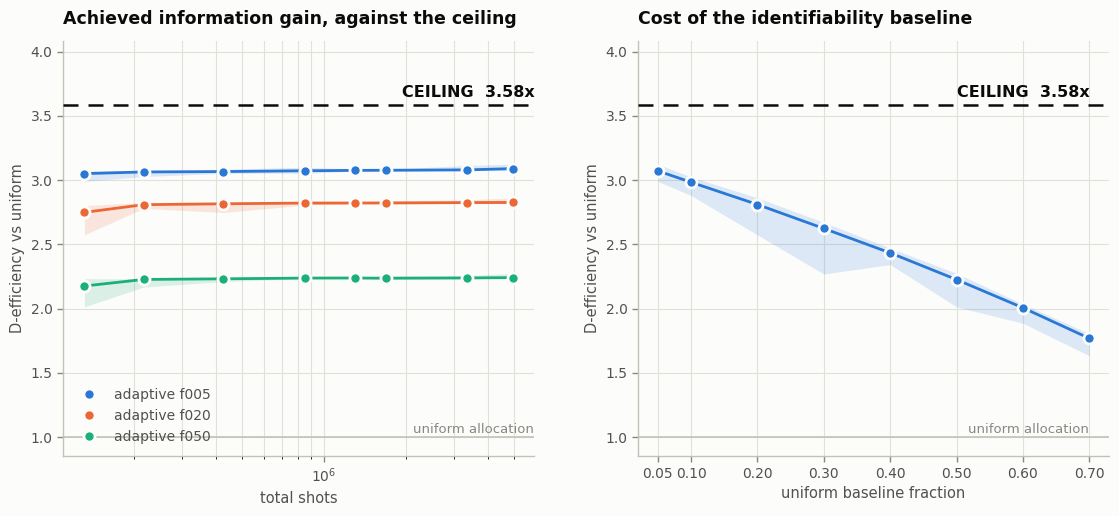

written: /workspace/IBCDFO/GST_POUNDERS/seed_sweep_experiments/analytic_ceiling.png


In [37]:
import matplotlib.pyplot as plt

# Palette: slots 1-3 of the validated categorical set (all-pairs clean in both modes),
# assigned by role and held fixed so filtering an arm never repaints the others.
SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
COLOURS = ["#2a78d6", "#eb6834", "#1baf7a"]
SHOWN = [a for a in ("adaptive_D_nofpr_f005", "adaptive_D_nofpr_f020", "adaptive_D_nofpr_f050")
         if a in set(adaptive.arm)]

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), facecolor=SURFACE)
fig.subplots_adjust(wspace=0.22)


def dress(ax, xlabel, ylabel, title):
    ax.set_facecolor(SURFACE)
    ax.grid(True, which="both", color=GRID, lw=0.8, ls="-", zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
        ax.spines[side].set_linewidth(1.0)
    ax.tick_params(colors=MUTED, labelcolor=INK2, length=4, width=1.0)
    ax.set_xlabel(xlabel, color=INK2, fontsize=10.5)
    ax.set_ylabel(ylabel, color=INK2, fontsize=10.5)
    ax.set_title(title, color=INK, fontsize=12.5, fontweight="semibold", loc="left", pad=12)


def reference_lines(ax, x_right):
    ax.axhline(CEILING, color=INK, lw=1.8, ls=(0, (6, 4)), zorder=5)
    ax.axhline(1.0, color=AXIS, lw=1.2, zorder=1)
    ax.text(x_right, CEILING * 1.012, f"CEILING  {CEILING:.2f}x", ha="right", va="bottom",
            color=INK, fontsize=11.5, fontweight="semibold", zorder=6)
    ax.text(x_right, 1.012, "uniform allocation", ha="right", va="bottom", color=MUTED,
            fontsize=9.5, zorder=6)


# ---- left: achieved vs shots, against the hard ceiling ---------------------------------
ax = axes[0]
for arm, colour in zip(SHOWN, COLOURS):
    g = (adaptive[adaptive.arm == arm]
         .groupby("budget")
         .agg(x=("shots", "median"), y=("d_eff", "median"),
              lo=("d_eff", "min"), hi=("d_eff", "max"))
         .sort_values("x"))
    ax.fill_between(g["x"], g["lo"], g["hi"], color=colour, alpha=0.15, lw=0, zorder=2)
    ax.plot(g["x"], g["y"], color=colour, lw=2.0, zorder=3)
    ax.plot(g["x"], g["y"], "o", ms=8, color=colour, mec=SURFACE, mew=2.0, zorder=4,
            label=f"adaptive f{arm.split('_f')[1]}")
ax.set_xscale("log")
ax.set_ylim(0.85, CEILING * 1.14)
dress(ax, "total shots", "D-efficiency vs uniform",
      "Achieved information gain, against the ceiling")
reference_lines(ax, ax.get_xlim()[1])
leg = ax.legend(frameon=False, fontsize=10, loc="lower left")
for t in leg.get_texts():
    t.set_color(INK2)

# ---- right: achieved vs baseline fraction ----------------------------------------------
ax = axes[1]
fr = sorted(int(a.split("_f")[1]) for a in adaptive.arm.unique())
x = np.array(fr, dtype=float) / 100.0
stat = np.array([[adaptive[adaptive.arm == f"adaptive_D_nofpr_f{f:03d}"]["d_eff"].agg(s)
                  for s in ("mean", "min", "max")] for f in fr])
ax.fill_between(x, stat[:, 1], stat[:, 2], color=COLOURS[0], alpha=0.15, lw=0, zorder=2)
ax.plot(x, stat[:, 0], color=COLOURS[0], lw=2.0, zorder=3)
ax.plot(x, stat[:, 0], "o", ms=8, color=COLOURS[0], mec=SURFACE, mew=2.0, zorder=4)
ax.set_xticks(x)
ax.set_xticklabels([f"{v:.2f}" for v in x])
ax.set_xlim(x.min() - 0.03, x.max() + 0.03)
ax.set_ylim(0.85, CEILING * 1.14)
dress(ax, "uniform baseline fraction", "D-efficiency vs uniform",
      "Cost of the identifiability baseline")
reference_lines(ax, x.max())

fig.savefig(SSE / "analytic_ceiling.png", dpi=170, bbox_inches="tight", facecolor=SURFACE)
plt.show()
print(f"written: {SSE / 'analytic_ceiling.png'}")

## Infidelity, reported separately

The measured infidelity multiplier is an **empirical observation**, not something the ceiling
above constrains. It is included because it is what the paper reports, and because the two
metrics agreeing is a real check: infidelity and diamond distance are computed differently and
scale differently (`N^-1` vs `N^-1/2`), so landing on a common shot multiplier is corroboration
rather than restatement.

Method: fit `log(metric) = a*log(shots) + b` per arm. If the arms are parallel, the horizontal
offset between two lines is constant and *is* the shot multiplier, `exp((b_arm - b_lm)/a)`.
Parallelism is checked rather than assumed.

In [38]:
METRICS = {"infidelity": "mean_gate_entanglement_infidelity_to_truth",
           "diamond": "mean_gate_diamond_distance_to_truth"}
BASE_ARM = "lm"

rows = []
for run in sorted(SSE.glob("all_methods_comparison_*")):
    if not run.name.rsplit("_", 1)[1].isdigit():
        continue
    for sd in sorted(run.glob("seed_*")):
        for arm in sorted(a for a in sd.iterdir() if a.is_dir()):
            f = arm / "summary.json"
            if not f.exists():
                continue
            s = json.loads(f.read_text())
            rows.append(dict(arm=arm.name, seed=int(sd.name.split("_")[1]),
                             shots=s.get("accounted_revealed_shots"),
                             **{k: s.get(v) for k, v in METRICS.items()}))
runs = pd.DataFrame(rows).dropna(subset=["shots"])
ARMS = [BASE_ARM] + sorted(a for a in set(runs.arm) if a.startswith("adaptive_D_nofpr_f"))
runs = runs[runs.arm.isin(ARMS)]

print(f"{'metric':<12}{'common slope':>14}{'theory':>9}{'per-arm range':>22}{'parallel?':>11}")
FIT = {}
for metric, theory in (("infidelity", -1.0), ("diamond", -0.5)):
    q = runs.dropna(subset=[metric])
    X = pd.get_dummies(q.arm).astype(float)
    A = np.column_stack([np.log(q.shots).to_numpy(), X.to_numpy()])
    c, *_ = np.linalg.lstsq(A, np.log(q[metric]).to_numpy(), rcond=None)
    FIT[metric] = (float(c[0]), dict(zip(X.columns, c[1:])))
    own = [np.polyfit(np.log(runs[runs.arm == a].shots),
                      np.log(runs[runs.arm == a][metric].astype(float)), 1)[0] for a in ARMS]
    print(f"{metric:<12}{c[0]:>14.3f}{theory:>9.1f}"
          f"{f'{min(own):+.3f} to {max(own):+.3f}':>22}"
          f"{('yes' if max(own) - min(own) < 0.2 else 'NO'):>11}")

print(f"\n{'arm':<24}{'infidelity':>14}{'diamond':>12}{'D-eff achieved':>17}")
for arm in ARMS[1:]:
    cells = []
    for metric in ("infidelity", "diamond"):
        a, icpt = FIT[metric]
        cells.append(f"{np.exp((icpt[arm] - icpt[BASE_ARM]) / a):.2f}x")
    d = tab.loc[arm, "mean"] if arm in tab.index else float("nan")
    print(f"{arm:<24}{cells[0]:>14}{cells[1]:>12}{d:>16.2f}x")

print("\nThe first two columns are observations about a different quantity. The D-optimality")
print("ceiling bounds only the third; a value exceeding it in the first two is not a")
print("contradiction, and an earlier version of this notebook was wrong to imply otherwise.")

metric        common slope   theory         per-arm range  parallel?
infidelity          -0.979     -1.0      -1.083 to -0.925        yes
diamond             -0.512     -0.5      -0.555 to -0.485        yes

arm                         infidelity     diamond   D-eff achieved
adaptive_D_nofpr_f005            3.29x       3.32x            3.07x
adaptive_D_nofpr_f010            3.08x       2.84x            2.98x
adaptive_D_nofpr_f020            2.79x       2.77x            2.81x
adaptive_D_nofpr_f030            2.38x       2.53x            2.62x
adaptive_D_nofpr_f040            2.44x       2.20x            2.43x
adaptive_D_nofpr_f050            2.12x       2.09x            2.23x
adaptive_D_nofpr_f060            1.96x       1.87x            2.01x
adaptive_D_nofpr_f070            1.63x       1.63x            1.77x

The first two columns are observations about a different quantity. The D-optimality
ceiling bounds only the third; a value exceeding it in the first two is not a
contradiction, an